# Evaluación y Selección de Modelos WESAD: ML vs DL

Este cuaderno presenta el flujo de trabajo definitivo para la evaluación, comparación y selección de la arquitectura óptima para la detección de estrés y estados afectivos utilizando el dataset WESAD.

**Objetivos del Estudio:**
1.  **Análisis del Espacio Latente:** Visualizar la separabilidad de las clases (Baseline, Stress, Amusement, Meditation) mediante PCA y t-SNE.
2.  **Benchmark de Machine Learning:** Establecer una línea base de rendimiento utilizando características extraídas manualmente (Feature Engineering) con algoritmos clásicos (XGBoost, RF, SVM, KNN).
3.  **Deep Learning (End-to-End):** Evaluar el rendimiento de redes neuronales convolucionales (InceptionTime) aplicadas directamente sobre señales fisiológicas crudas.
4.  **Estudio de Ablación y Selección de Hardware:** Determinar si un sistema basado únicamente en **ECG** (procesado con Deep Learning) puede igualar el rendimiento de un sistema multimodal complejo (Pecho completo), justificando así la simplificación del hardware.

**Estructura de Datos:**
*   Entrada ML: `wesad_features_all.parquet` (Datos tabulares).
*   Entrada DL: `wesad_signals_dl.pkl` (Tensores de series temporales).

# 1. Configuración del Entorno y Carga de Datos (Global)

Este bloque inicializa el entorno de trabajo para garantizar la reproducibilidad del estudio comparativo (ML vs DL).

**Acciones:**
1.  **Montaje de Drive y Rutas:** Se define `models3/` como el directorio de salida para evitar sobrescribir experimentos previos.
2.  **Semilla Global (SEED):** Se fija en `42` para Numpy, Pandas, Sklearn y TensorFlow.
3.  **Carga de Datos:**
    * *Features (ML):* `wesad_features_all.parquet`. Se aplica limpieza de infinitos y nulos.
    * *Señales Crudas (DL):* `wesad_signals_dl.pkl`. Se estructura como Tensor 3D `(Muestras, Tiempo, Canales)`.
4.  **División Estratificada Única:** Se generan los índices para Train (70%), Validation (15%) y Test (15%) una sola vez. Estos índices se usarán para sincronizar los datos de ML y DL.

In [ ]:
import os
import sys
import pickle
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de ML y DL
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.impute import SimpleImputer
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers, backend as K

# 1. Configuración Global y Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism() # Para GPU determinista en Colab

# Configuración Visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 2. Rutas y Drive
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/2025-2/ISB/Feature_extraction/'
DATA_PATH = BASE_PATH
MODELS_PATH = os.path.join(BASE_PATH, 'models3/') # Nueva carpeta solicitada

if not os.path.exists(MODELS_PATH):
    os.makedirs(MODELS_PATH)
    print(f"[INFO] Carpeta creada: {MODELS_PATH}")
else:
    print(f"[INFO] Guardando en carpeta existente: {MODELS_PATH}")

# ---------------------------------------------------------
# 3. Carga y Preprocesamiento Unificado
# ---------------------------------------------------------

# A) Cargar Features (ML)
print("\n[1/3] Cargando Features (ML)...")
df_features = pd.read_parquet(os.path.join(DATA_PATH, 'wesad_features_all.parquet'))

# Separar Metadatos
meta_cols = ['Subject', 'Condition', 'Label', 'Y_Valence', 'Y_Arousal', 'Y_STAI',
             'Y_PANAS_Pos', 'Y_PANAS_Neg', 'Y_SSSQ_Motiv']
feature_cols = [c for c in df_features.columns if c not in meta_cols]

X_raw_ml = df_features[feature_cols].values
y_labels = df_features['Condition'].values

# Limpieza ML (Inf/NaN)
X_raw_ml = np.where(np.isinf(X_raw_ml), np.nan, X_raw_ml)
imputer = SimpleImputer(strategy='median')
X_ml = imputer.fit_transform(X_raw_ml)
scaler = StandardScaler()
X_ml = scaler.fit_transform(X_ml) # Estandarización final

# Codificación de Etiquetas
le = LabelEncoder()
y_enc = le.fit_transform(y_labels)
classes = le.classes_
print(f" -> Dimensiones ML: {X_ml.shape}")
print(f" -> Clases: {classes}")

# B) Cargar Señales Crudas (DL)
print("\n[2/3] Cargando Señales Crudas (DL)...")
with open(os.path.join(DATA_PATH, 'wesad_signals_dl.pkl'), 'rb') as f:
    raw_data_list = pickle.load(f)

# Identificar canales dinámicamente y ordenar alfabéticamente para consistencia
sample_keys = raw_data_list[0].keys()
signal_keys = sorted([k for k in sample_keys if k.startswith('Signal_') or k.startswith('RAW_')])
print(f" -> Canales detectados ({len(signal_keys)}): {signal_keys}")

# Construir Tensor 3D
X_dl_list = [np.column_stack([item[k] for k in signal_keys]) for item in raw_data_list]
X_dl = np.array(X_dl_list, dtype=np.float32) # float32 para ahorrar memoria GPU
print(f" -> Dimensiones DL: {X_dl.shape}")

# Validación de Integridad
assert len(X_ml) == len(X_dl), "ERROR CRÍTICO: Los datasets ML y DL no tienen el mismo número de muestras."

# ---------------------------------------------------------
# 4. División Global de Datos (Indices Únicos)
# ---------------------------------------------------------
print("\n[3/3] Generando Índices de División Globales...")

# Split 1: Train (70%) vs Temp (30%)
split_1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
train_idx, temp_idx = next(split_1.split(X_ml, y_enc))

# Split 2: Validation (15%) vs Test (15%) - Se divide Temp a la mitad
split_2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
val_idx_rel, test_idx_rel = next(split_2.split(X_ml[temp_idx], y_enc[temp_idx]))

# Mapear índices relativos a globales
val_idx = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

print(f" -> Train: {len(train_idx)} muestras")
print(f" -> Val:   {len(val_idx)} muestras")
print(f" -> Test:  {len(test_idx)} muestras")
print("\n[INFO] Configuración completada. Listos para entrenar.")

Mounted at /content/drive
[INFO] Carpeta creada: /content/drive/MyDrive/2025-2/ISB/Feature_extraction/models3/

[1/3] Cargando Features (ML)...


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [  2   3   4   5   6   7  25  26  84  85  86  87  88  89 107 108]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


 -> Dimensiones ML: (1395, 188)
 -> Clases: ['Amusement' 'Baseline' 'Meditation' 'Stress']

[2/3] Cargando Señales Crudas (DL)...
 -> Canales detectados (9): ['RAW_ACC_Chest', 'RAW_ACC_Wrist', 'RAW_BVP', 'RAW_ECG', 'RAW_EDA_Chest', 'RAW_EDA_Wrist', 'RAW_EMG', 'RAW_RESP', 'RAW_TEMP']
 -> Dimensiones DL: (1395, 15360, 9)

[3/3] Generando Índices de División Globales...
 -> Train: 976 muestras
 -> Val:   209 muestras
 -> Test:  210 muestras

[INFO] Configuración completada. Listos para entrenar.


# 2. Benchmark de Machine Learning (Datos Tabulares)

Se establece la línea base de rendimiento utilizando algoritmos clásicos sobre las características extraídas manualmente (`Features`).

**Modelos Evaluados:**
1.  **k-NN (k-Nearest Neighbors):** Basado en proximidad local.
2.  **SVM (Support Vector Machine):** Kernel RBF para separabilidad no lineal.
3.  **Random Forest:** Ensamble tipo Bagging.
4.  **XGBoost:** Ensamble tipo Boosting (Gradient Boosting), generalmente el estado del arte en datos tabulares.

**Protocolo:**
* Entrenamiento sobre el conjunto `Train` (70%).
* Evaluación final sobre el conjunto `Test` (15%).
* **Guardado:** Todos los modelos se serializan en `models2/` para su uso posterior o despliegue.

Dimensiones ML Train: (976, 188)
Dimensiones ML Test:  (210, 188)

[INFO] Iniciando entrenamiento y guardado de modelos ML...
 -> Entrenando KNN...
 -> Entrenando SVM...
 -> Entrenando Random Forest...
 -> Entrenando XGBoost...
[INFO] Benchmark ML completado.

--- Resultados Benchmark ML (Ordenado por Detección de Estrés) ---


,Accuracy,F1_Macro,F1_Stress,Recall_Stress,Archivo
Modelo,,,,,
Random Forest,0.900000,0.844186,0.957447,0.957447,ml_random_forest.pkl
XGBoost,0.942857,0.925007,0.947368,0.957447,ml_xgboost.pkl
SVM,0.880952,0.826287,0.920000,0.978723,ml_svm.pkl
KNN,0.852381,0.813735,0.860215,0.851064,ml_knn.pkl


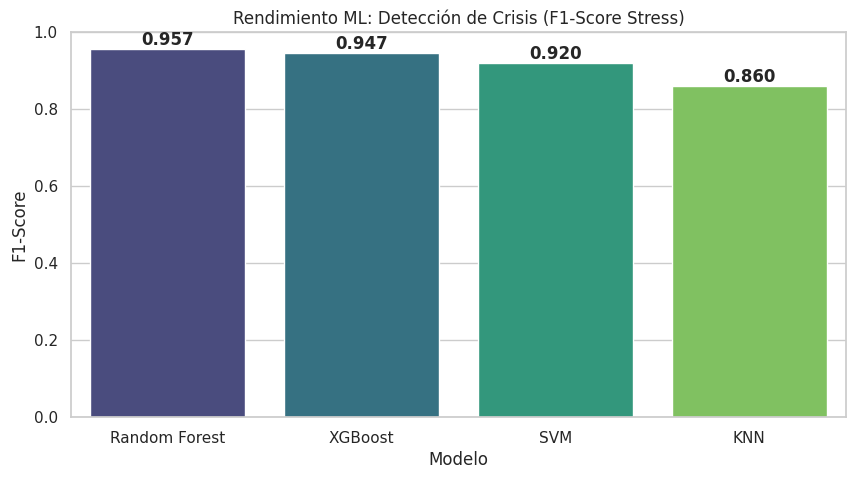

In [ ]:
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# ---------------------------------------------------------
# 1. Preparación de Datos ML (Slicing)
# ---------------------------------------------------------
# Usamos los mismos índices globales generados en el paso anterior
X_train_ml = X_ml[train_idx]
y_train = y_enc[train_idx]

X_test_ml = X_ml[test_idx]
y_test = y_enc[test_idx]

print(f"Dimensiones ML Train: {X_train_ml.shape}")
print(f"Dimensiones ML Test:  {X_test_ml.shape}")

# ---------------------------------------------------------
# 2. Configuración de Modelos
# ---------------------------------------------------------
# Diccionario de modelos con hiperparámetros estándar/robustos
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVM": SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        eval_metric='mlogloss',
        random_state=SEED,
        device='cuda', # Intenta usar GPU si está disponible
        verbosity=0
    )
}

# ---------------------------------------------------------
# 3. Bucle de Entrenamiento y Guardado
# ---------------------------------------------------------
ml_results = []

print("\n[INFO] Iniciando entrenamiento y guardado de modelos ML...")

for name, model in models_dict.items():
    print(f" -> Entrenando {name}...")

    # A) Entrenamiento
    model.fit(X_train_ml, y_train)

    # B) Guardado del Modelo (Pickle)
    filename = f"ml_{name.lower().replace(' ', '_')}.pkl"
    save_path = os.path.join(MODELS_PATH, filename)
    with open(save_path, 'wb') as f:
        pickle.dump(model, f)

    # C) Evaluación en Test
    y_pred = model.predict(X_test_ml)
    report = classification_report(y_test, y_pred, target_names=classes, output_dict=True)

    # D) Guardar métricas
    ml_results.append({
        'Modelo': name,
        'Accuracy': report['accuracy'],
        'F1_Macro': report['macro avg']['f1-score'],
        'F1_Stress': report['Stress']['f1-score'], # Métrica crítica
        'Recall_Stress': report['Stress']['recall'],
        'Archivo': filename
    })

print("[INFO] Benchmark ML completado.")

# ---------------------------------------------------------
# 4. Visualización de Resultados
# ---------------------------------------------------------
df_ml_results = pd.DataFrame(ml_results).set_index('Modelo').sort_values(by='F1_Stress', ascending=False)

print("\n--- Resultados Benchmark ML (Ordenado por Detección de Estrés) ---")
display(df_ml_results)

# Gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=df_ml_results.index, y=df_ml_results['F1_Stress'], hue=df_ml_results.index, palette='viridis', legend=False)
plt.title('Rendimiento ML: Detección de Crisis (F1-Score Stress)')
plt.ylabel('F1-Score')
plt.ylim(0, 1.0)
for i, v in enumerate(df_ml_results['F1_Stress']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

Aunque aparentemente veamos que RF obtuvo un F1_Stress mayor a XGBoost, vemos que sacrifica rendimiento en las otras métricas, como su accuracy, esto puede indicar que está ajustandose mucho a los casos de estrés, pero que se equivoca más con el resto de casos. Mientras que el modelo de XGBoost responde mejor, siendo más confiable en este tipo de data, sin generar tantas falsas alarmas en otros estados emocionales.


# 3. Benchmark de Deep Learning (Arquitecturas)

En esta fase comparamos tres enfoques de Redes Neuronales:
1.  **MLP (Feature-based):** Deep Learning aplicado a las características manuales. Sirve para ver si una red neuronal puede encontrar relaciones no lineales que XGBoost ignoró.
2.  **CNN-LSTM (Raw Signals):** Arquitectura híbrida clásica para series temporales. Las capas CNN extraen morfología local y la LSTM captura dependencias temporales largas.
3.  **InceptionTime (Raw Signals):** Estado del arte en clasificación de series temporales. Utiliza bloques Inception con múltiples tamaños de kernel (10, 20, 40) en paralelo para capturar patrones de corta y larga duración simultáneamente.

**Estrategia de Entrenamiento:**
* **Optimizador:** Adam con `Learning Rate` dinámico (`ReduceLROnPlateau`).
* **Regularización:** `EarlyStopping` (Paciencia=15) para evitar sobreajuste y `Dropout`.
* **Limpieza:** Se invoca `clear_session()` entre modelos para evitar fugas de memoria en la GPU.

In [ ]:
# ---------------------------------------------------------
# Corrección: Generar tensores de DL usando los índices globales
# ---------------------------------------------------------
# Aplicamos los mismos índices que usamos en ML para garantizar
# que ambos modelos vean EXACTAMENTE a los mismos pacientes.

X_train_dl = X_dl[train_idx]
X_val_dl   = X_dl[val_idx]
X_test_dl  = X_dl[test_idx]

print(f"Dimensiones DL Train: {X_train_dl.shape}")
print(f"Dimensiones DL Val:   {X_val_dl.shape}")
print(f"Dimensiones DL Test:  {X_test_dl.shape}")

Dimensiones DL Train: (976, 15360, 9)
Dimensiones DL Val:   (209, 15360, 9)
Dimensiones DL Test:  (210, 15360, 9)


In [ ]:
from tensorflow.keras.utils import to_categorical

# Configuración DL
EPOCHS = 100
BATCH_SIZE = 32
# Aseguramos que las dimensiones sean correctas
input_shape_dl = (X_train_dl.shape[1], X_train_dl.shape[2])
input_shape_ml = (X_train_ml.shape[1],) # Tupla de 1 elemento (features,)
num_classes = len(classes)

# Callbacks Comunes
def get_callbacks(filename):
    return [
        callbacks.ModelCheckpoint(
            filepath=os.path.join(MODELS_PATH, filename),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    ]

# ---------------------------------------------------------
# A. Definición de Arquitecturas (Firmas Unificadas)
# ---------------------------------------------------------

def build_mlp(input_shape, num_classes):
    """Deep Learning sobre Features Tabulares"""
    # CORRECCIÓN: input_shape entra directo, no se envuelve en otra tupla
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="MLP_Features")
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_cnn_lstm(input_shape, num_classes):
    """Híbrido CNN-LSTM sobre Señales Crudas"""
    inputs = layers.Input(shape=input_shape)
    # Extracción de características (CNN)
    x = layers.Conv1D(64, kernel_size=64, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=4)(x)
    x = layers.Conv1D(128, kernel_size=32, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=4)(x)
    # Modelado Temporal (LSTM)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="CNN_LSTM_Raw")
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def inception_module(x, filters):
    # Ramas paralelas con diferentes kernels
    conv1 = layers.Conv1D(filters, 10, padding='same', activation='relu')(x)
    conv2 = layers.Conv1D(filters, 20, padding='same', activation='relu')(x)
    conv3 = layers.Conv1D(filters, 40, padding='same', activation='relu')(x)
    maxpool = layers.MaxPooling1D(3, strides=1, padding='same')(x)
    convpool = layers.Conv1D(filters, 1, padding='same', activation='relu')(maxpool)
    # Concatenación
    out = layers.Concatenate(axis=-1)([conv1, conv2, conv3, convpool])
    out = layers.BatchNormalization()(out)
    return out

def build_inception(input_shape, num_classes):
    """Arquitectura InceptionTime"""
    inputs = layers.Input(shape=input_shape)
    x = inputs
    # Bloque Inception con conexión residual
    x_res = layers.Conv1D(128, 1, padding='same')(x) # Ajuste de dimensiones para suma residual
    x = inception_module(x, 32)
    x = layers.Add()([x, x_res])
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x) # Downsampling

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="InceptionTime_Raw")
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

# ---------------------------------------------------------
# B. Bucle de Entrenamiento DL
# ---------------------------------------------------------
dl_results = []
# Lista de tuplas: (Nombre, FunciónBuilder, DatosX_Train, DatosX_Test, InputShape)
models_config = [
    ("MLP (Features)", build_mlp, X_train_ml, X_test_ml, input_shape_ml),
    ("CNN-LSTM (Raw)", build_cnn_lstm, X_train_dl, X_test_dl, input_shape_dl),
    ("InceptionTime (Raw)", build_inception, X_train_dl, X_test_dl, input_shape_dl)
]

print("\n[INFO] Iniciando Benchmark de Deep Learning...")

for name, builder, X_tr, X_te, shape_in in models_config:
    print(f"\n--- Entrenando {name} ---")

    # 1. Limpieza de Memoria
    tf.keras.backend.clear_session()
    gc.collect()

    # 2. Construcción y Callbacks
    model = builder(shape_in, num_classes)
    fname = f"dl_{name.split()[0].lower().replace('-','')}.keras"
    cbs = get_callbacks(fname)

    # 3. Entrenamiento
    history = model.fit(
        X_tr, y_train,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=cbs,
        verbose=1
    )

    # 4. Cargar mejor modelo guardado y Evaluar
    best_model = models.load_model(os.path.join(MODELS_PATH, fname))
    y_pred_probs = best_model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Métricas
    report = classification_report(y_test, y_pred, target_names=classes, output_dict=True)
    dl_results.append({
        'Modelo': name,
        'Accuracy': report['accuracy'],
        'F1_Macro': report['macro avg']['f1-score'],
        'F1_Stress': report['Stress']['f1-score'],
        'Archivo': fname
    })

    print(f" -> {name} Finalizado. F1-Stress: {report['Stress']['f1-score']:.4f}")

# ---------------------------------------------------------
# C. Resultados DL
# ---------------------------------------------------------
df_dl_results = pd.DataFrame(dl_results).set_index('Modelo').sort_values(by='F1_Stress', ascending=False)
print("\n--- Resultados Benchmark Deep Learning ---")
display(df_dl_results)


[INFO] Iniciando Benchmark de Deep Learning...

--- Entrenando MLP (Features) ---
Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3353 - loss: 1.8202
Epoch 1: val_accuracy improved from -inf to 0.65306, saving model to /content/drive/MyDrive/2025-2/ISB/Feature_extraction/models3/dl_mlp.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.3391 - loss: 1.8068 - val_accuracy: 0.6531 - val_loss: 0.8937 - learning_rate: 0.0010
Epoch 2/100
21/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6801 - loss: 0.8629
Epoch 2: val_accuracy improved from 0.65306 to 0.77551, saving model to /content/drive/MyDrive/2025-2/ISB/Feature_extraction/models3/dl_mlp.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6838 - loss: 0.8512 - val_accuracy: 0.7755 - val_loss: 0.6806 - learning_rate: 0.0010
Epoch 3/100
23/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7926 - loss: 0.5741
Epoch 3: val_accuracy improved from 0.77551 to 0.82313, saving model to /content/drive/MyDri

 -> InceptionTime (Raw) Finalizado. F1-Stress: 0.9592

--- Resultados Benchmark Deep Learning ---


,Accuracy,F1_Macro,F1_Stress,Archivo
Modelo,,,,
InceptionTime (Raw),0.961905,0.942688,0.959184,dl_inceptiontime.keras
MLP (Features),0.923810,0.897551,0.938776,dl_mlp.keras
CNN-LSTM (Raw),0.514286,0.451054,0.494118,dl_cnnlstm.keras


# 4. Interpretabilidad y Selección de Características

Antes de proceder a la reducción de hardware (Ablación), analizamos qué información utilizan los mejores modelos para tomar decisiones. Esto justifica la selección de los escenarios de ablación.

**Metodología: Importancia por Permutación**
Esta técnica evalúa la importancia de una característica (o sensor) mezclando aleatoriamente sus valores en el conjunto de prueba y midiendo la caída en el rendimiento del modelo.
* **Si el rendimiento cae drásticamente:** La característica es crítica.
* **Si el rendimiento se mantiene:** La característica es redundante o ruido.

**Experimentos:**
1.  **ML (XGBoost):** Evaluamos las 20 características estadísticas más importantes.
2.  **DL (InceptionTime):** Evaluamos la importancia crítica de cada **Canal de Sensor** (ECG, EDA, EMG, etc.) para validar la hipótesis de que el ECG contiene la mayor parte de la información discriminativa.

[INFO] Analizando Importancia en XGBoost (ML)...

--- Top 5 Características Críticas (XGBoost) ---
 BVP_HRV_HFD: 0.1524 (Caída en Accuracy)
 BVP_HRV_LZC: 0.0533 (Caída en Accuracy)
 BVP_HRV_MFDFA_alpha1_Fluctuation: 0.0267 (Caída en Accuracy)
 EDA_Tonic_Mean: 0.0257 (Caída en Accuracy)
 BVP_HRV_CMSEn: 0.0181 (Caída en Accuracy)


/tmp/ipython-input-2213423088.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_result.importances_mean[sorted_idx[:top_n]], y=feature_names[sorted_idx[:top_n]], palette='viridis', legend=False)


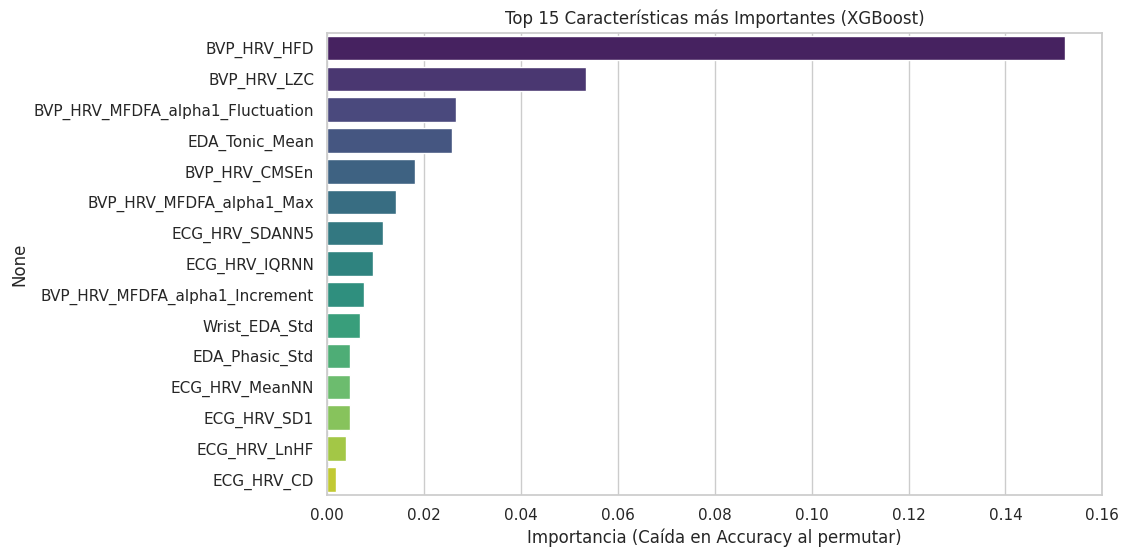


[INFO] Analizando Importancia de Sensores en InceptionTime (DL)...


Accuracy Base (Todos los canales): 0.9619
 -> Canal ACC_Chest: Caída de 0.2571
 -> Canal ACC_Wrist: Caída de 0.0381
 -> Canal BVP: Caída de 0.0190
 -> Canal ECG: Caída de 0.1143
 -> Canal EDA_Chest: Caída de 0.0952
 -> Canal EDA_Wrist: Caída de 0.0238
 -> Canal EMG: Caída de 0.2333
 -> Canal RESP: Caída de 0.1095
 -> Canal TEMP: Caída de 0.0095


/tmp/ipython-input-2213423088.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Canal', data=df_imp_dl, palette='magma', legend=False)


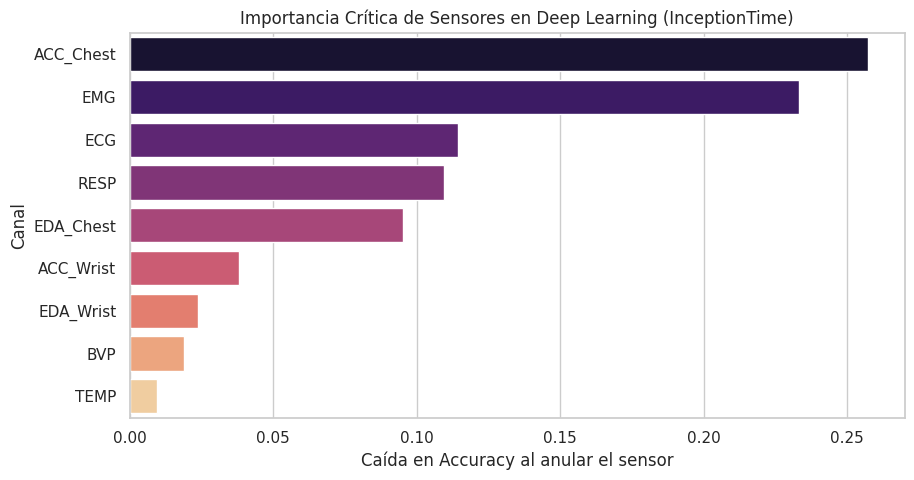

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------
# A. Interpretabilidad ML: XGBoost (Features)
# ---------------------------------------------------------
print("[INFO] Analizando Importancia en XGBoost (ML)...")

# 1. Cargar modelo
xgb_path = os.path.join(MODELS_PATH, 'ml_xgboost.pkl')
with open(xgb_path, 'rb') as f:
    best_xgb = pickle.load(f)

# 2. Calcular Permutation Importance (Sobre Test Set)
# Repetimos 5 veces para estabilidad estadística
perm_result = permutation_importance(
    best_xgb, X_test_ml, y_test,
    n_repeats=5, random_state=SEED, n_jobs=-1
)

# 3. Procesar resultados
# Recuperar nombres de columnas (Features)
feature_names = df_features.columns.drop(meta_cols)
# Filtrar nombres para coincidir con las columnas válidas (si hubo eliminación por NaNs)
# Nota: Asumimos que feature_names coincide con X_ml. Si X_ml tuvo columnas borradas, esto requiere ajuste.
# Para este dataset limpio, usualmente coinciden.

sorted_idx = perm_result.importances_mean.argsort()[::-1]
top_n = 15

print("\n--- Top 5 Características Críticas (XGBoost) ---")
for i in sorted_idx[:5]:
    print(f" {feature_names[i]}: {perm_result.importances_mean[i]:.4f} (Caída en Accuracy)")

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=perm_result.importances_mean[sorted_idx[:top_n]], y=feature_names[sorted_idx[:top_n]], palette='viridis', legend=False)
plt.title(f'Top {top_n} Características más Importantes (XGBoost)')
plt.xlabel('Importancia (Caída en Accuracy al permutar)')
plt.show()

# ---------------------------------------------------------
# B. Interpretabilidad DL: InceptionTime (Canales)
# ---------------------------------------------------------
print("\n[INFO] Analizando Importancia de Sensores en InceptionTime (DL)...")

# 1. Cargar modelo
inception_path = os.path.join(MODELS_PATH, 'dl_inceptiontime.keras')
best_inception = models.load_model(inception_path)

# 2. Línea base
y_pred_base = np.argmax(best_inception.predict(X_test_dl, verbose=0), axis=1)
acc_baseline = accuracy_score(y_test, y_pred_base)
print(f"Accuracy Base (Todos los canales): {acc_baseline:.4f}")

# 3. Bucle de Permutación por Canal
channel_importances = []
channel_names = [k.replace('RAW_', '').replace('Signal_', '') for k in signal_keys]

for i, ch_name in enumerate(channel_names):
    # Copia temporal para no dañar el original
    X_temp = X_test_dl.copy()

    # PERMUTACIÓN: Mezclamos solo el canal 'i' a través de las muestras
    # (Rompemos la correlación entre ese sensor y la etiqueta)
    np.random.shuffle(X_temp[:, :, i])

    # Predicción
    y_pred_perm = np.argmax(best_inception.predict(X_temp, verbose=0), axis=1)
    acc_perm = accuracy_score(y_test, y_pred_perm)

    # Importancia = Cuánto cayó la precisión
    drop = acc_baseline - acc_perm
    channel_importances.append({'Canal': ch_name, 'Importancia': drop})
    print(f" -> Canal {ch_name}: Caída de {drop:.4f}")

# 4. Visualización
df_imp_dl = pd.DataFrame(channel_importances).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Canal', data=df_imp_dl, palette='magma', legend=False)
plt.title('Importancia Crítica de Sensores en Deep Learning (InceptionTime)')
plt.xlabel('Caída en Accuracy al anular el sensor')
plt.show()

# 5. Estudio de Ablación: Validación de Hipótesis de Hardware

Este es el experimento crítico del estudio. Evaluamos si es posible reducir la complejidad del hardware manteniendo un rendimiento clínico aceptable.

Se entrenan instancias independientes de la arquitectura ganadora (**InceptionTime**) restringiendo la entrada a subconjuntos específicos de sensores:

1.  **Full Model:** Referencia (9 canales).
2.  **Chest Multimodal:** Todos los sensores de pecho (ECG, EDA, EMG, Resp, Acc).
3.  **Wrist (Wearable):** Sensores de muñeca comerciales (BVP, EDA, Temp, Acc).
4.  **ECG Only:** Hipótesis central. Un solo canal de derivación cardíaca.

**Nota:** Se utiliza una estrategia de entrenamiento más robusta (`Patience=20`) para garantizar que los modelos con menos información (como ECG Only) tengan tiempo suficiente para converger.

In [ ]:
# ---------------------------------------------------------
# Corrección: Definir etiquetas (targets) usando los índices globales
# ---------------------------------------------------------
# Aseguramos que las etiquetas correspondan exactamente a los datos X

y_train = y_enc[train_idx]
y_val   = y_enc[val_idx]  # Esta es la que faltaba
y_test  = y_enc[test_idx]

print(f"Etiquetas sincronizadas:")
print(f" -> Train: {y_train.shape}")
print(f" -> Val:   {y_val.shape}")
print(f" -> Test:  {y_test.shape}")

Etiquetas sincronizadas:
 -> Train: (976,)
 -> Val:   (209,)
 -> Test:  (210,)


[INFO] Canales ECG: ['RAW_ECG']
[INFO] Canales Wrist: ['RAW_ACC_Wrist', 'RAW_BVP', 'RAW_EDA_Wrist', 'RAW_TEMP']

[INFO] Iniciando Torneo de Ablación (InceptionTime)...

 Escenario: Full Model (9 canales)
 -> Input Shape: (15360, 9)
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.3275 - loss: 1.4864 - val_accuracy: 0.4928 - val_loss: 1.3043 - learning_rate: 0.0010
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.4544 - loss: 1.2081 - val_accuracy: 0.4545 - val_loss: 1.2721 - learning_rate: 0.0010
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.5539 - loss: 1.1169 - val_accuracy: 0.4402 - val_loss: 1.2501 - learning_rate: 0.0010
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.6422 - loss: 1.0170 - val_accuracy: 0.4737 - val_loss: 1.2130 - learning_rate: 0.0010
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.6424 - loss: 0.9602 - val_accuracy: 0.5167 - val_loss: 1.1617 - learning_rate: 0.0010
Epo

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Num_Canales,Accuracy,F1_Stress,Precision_Stress,Recall_Stress,Archivo
Escenario,,,,,,
Full Model,9,0.976190,0.968421,0.958333,0.978723,abl_dl_full_model.keras
ECG Only,1,0.671429,0.927835,0.900000,0.957447,abl_dl_ecg_only.keras
Chest Multimodal,6,0.947619,0.921569,0.854545,1.000000,abl_dl_chest_multimodal.keras
Wrist (Wearable),4,0.695238,0.785714,0.891892,0.702128,abl_dl_wrist_wearable.keras


/tmp/ipython-input-3687160053.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_ablation.index, y=df_ablation['F1_Stress'], palette=colors)


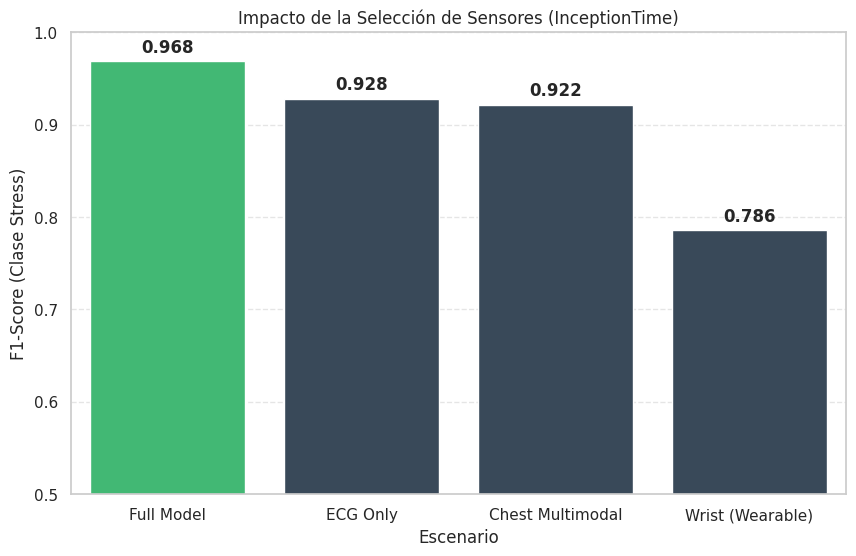

In [ ]:
# ---------------------------------------------------------
# Configuración del Estudio de Ablación
# ---------------------------------------------------------

# 1. Definir los índices de canales para cada escenario
# (Usamos signal_keys detectado en el Paso 1 para buscar los índices)
idx_ecg = [i for i, k in enumerate(signal_keys) if 'ECG' in k]
idx_chest = [i for i, k in enumerate(signal_keys) if 'Wrist' not in k and 'BVP' not in k]
idx_wrist = [i for i, k in enumerate(signal_keys) if 'Wrist' in k or 'BVP' in k or 'TEMP' in k]
idx_full = list(range(len(signal_keys))) # Todos

scenarios = {
    "Full Model": idx_full,
    "Chest Multimodal": idx_chest,
    "Wrist (Wearable)": idx_wrist,
    "ECG Only": idx_ecg
}

ablation_results = []

print(f"[INFO] Canales ECG: {[signal_keys[i] for i in idx_ecg]}")
print(f"[INFO] Canales Wrist: {[signal_keys[i] for i in idx_wrist]}")

# 2. Callbacks Robustos (Paciencia Aumentada)
def get_robust_callbacks(filename):
    return [
        callbacks.ModelCheckpoint(
            filepath=os.path.join(MODELS_PATH, filename),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        ),
        # Paciencia aumentada a 20 para permitir mejoras tardías
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1)
    ]

print("\n[INFO] Iniciando Torneo de Ablación (InceptionTime)...")

for name, indices in scenarios.items():
    print(f"\n=============================================")
    print(f" Escenario: {name} ({len(indices)} canales)")
    print(f"=============================================")

    # A) Slicing de Datos (Recortar tensor)
    X_train_sub = X_train_dl[:, :, indices]
    X_val_sub   = X_val_dl[:, :, indices] # Usamos el set de validación global
    X_test_sub  = X_test_dl[:, :, indices]

    input_shape_sub = (X_train_sub.shape[1], X_train_sub.shape[2])
    print(f" -> Input Shape: {input_shape_sub}")

    # B) Limpieza y Construcción
    tf.keras.backend.clear_session()
    gc.collect()

    model = build_inception(input_shape_sub, num_classes)
    fname = f"abl_dl_{name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.keras"

    # C) Entrenamiento Robusto
    history = model.fit(
        X_train_sub, y_train,
        validation_data=(X_val_sub, y_val), # Usamos validación explícita
        epochs=100, # Damos margen, EarlyStopping cortará si es necesario
        batch_size=32,
        callbacks=get_robust_callbacks(fname),
        verbose=1
    )

    # D) Evaluación del Mejor Modelo
    best_model = models.load_model(os.path.join(MODELS_PATH, fname))
    y_pred_probs = best_model.predict(X_test_sub, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # E) Métricas
    report = classification_report(y_test, y_pred, target_names=classes, output_dict=True)

    ablation_results.append({
        'Escenario': name,
        'Num_Canales': len(indices),
        'Accuracy': report['accuracy'],
        'F1_Stress': report['Stress']['f1-score'], # La métrica clave
        'Precision_Stress': report['Stress']['precision'],
        'Recall_Stress': report['Stress']['recall'],
        'Archivo': fname
    })

    print(f" -> Resultado {name}: F1-Stress = {report['Stress']['f1-score']:.4f}")

# ---------------------------------------------------------
# 3. Visualización Final Ablación
# ---------------------------------------------------------
df_ablation = pd.DataFrame(ablation_results).set_index('Escenario').sort_values(by='F1_Stress', ascending=False)

print("\n--- Resultados del Estudio de Ablación ---")
display(df_ablation)

# Gráfico Comparativo
plt.figure(figsize=(10, 6))
# Usamos una paleta divergente para resaltar al ganador
colors = ['#2ecc71' if x == df_ablation['F1_Stress'].max() else '#34495e' for x in df_ablation['F1_Stress']]
sns.barplot(x=df_ablation.index, y=df_ablation['F1_Stress'], palette=colors)

plt.title('Impacto de la Selección de Sensores (InceptionTime)')
plt.ylabel('F1-Score (Clase Stress)')
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(df_ablation['F1_Stress']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.show()

# 6. Consolidación de Resultados y Discusión Final

En esta etapa final, unificamos las métricas obtenidas en todas las fases del estudio para responder a la pregunta de investigación: **¿Es posible detectar crisis de ansiedad con precisión clínica utilizando un sistema de hardware reducido (ECG-Only) procesado con Deep Learning?**

**Entregables:**
1.  **Tabla Maestra:** Comparativa directa entre el mejor modelo clásico (XGBoost) y las variantes de Deep Learning.
2.  **Gráfico de "Torneo":** Visualización del F1-Score en estrés a través de las distintas configuraciones.
3.  **Matrices de Confusión Finales:** Comparación lado a lado de los errores cometidos por la mejor estrategia ML vs. la mejor estrategia DL.


TABLA MAESTRA DE RESULTADOS (TESIS)


,Enfoque,Configuración,Hardware,F1_Stress,Accuracy
0,Deep Learning (Ablation),InceptionTime (Full Model),Desconocido,0.968421,0.976190
1,Deep Learning (Raw),InceptionTime (Full),Full (Resp+EDA+ECG+EMG),0.959184,0.961905
2,Machine Learning (Features),Best ML (Random Forest),Full (Resp+EDA+ECG+EMG),0.957447,0.900000
3,Deep Learning (Ablation),InceptionTime (ECG Only),ECG (1 Canal),0.927835,0.671429
4,Deep Learning (Ablation),InceptionTime (Chest Multimodal),Chest (5 Canales),0.921569,0.947619
5,Deep Learning (Ablation),InceptionTime (Wrist (Wearable)),Wrist (4 Canales),0.785714,0.695238


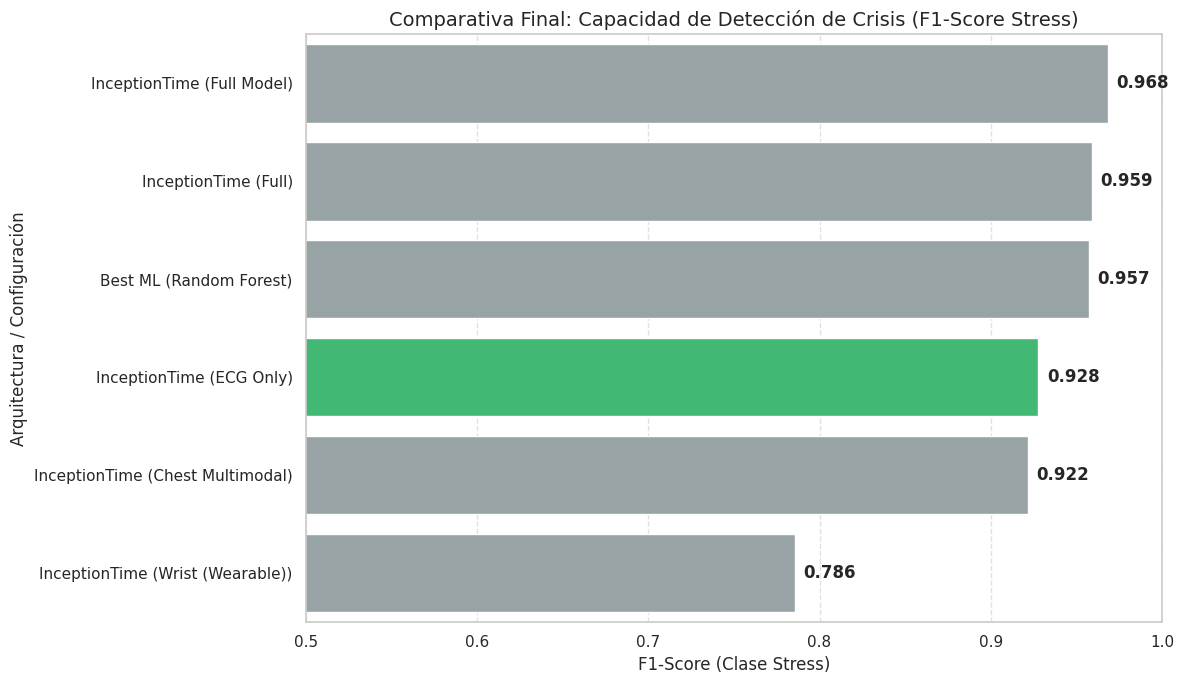


[INFO] Tabla maestra guardada en: /content/drive/MyDrive/2025-2/ISB/Feature_extraction/models3/tabla_resultados_finales_tesis.csv
[INFO] Proceso del Notebook finalizado exitosamente.


In [ ]:
# ---------------------------------------------------------
# 1. Unificación de Resultados (ML + DL + Ablación)
# ---------------------------------------------------------
final_summary = []

# Recuperar ML (Si existe)
if 'df_ml_results' in globals():
    # Tomamos el mejor de ML (XGBoost usualmente)
    best_ml = df_ml_results.iloc[0] # Asumimos que está ordenado
    final_summary.append({
        'Enfoque': 'Machine Learning (Features)',
        'Configuración': f"Best ML ({best_ml.name})",
        'Hardware': 'Full (Resp+EDA+ECG+EMG)',
        'F1_Stress': best_ml['F1_Stress'],
        'Accuracy': best_ml['Accuracy']
    })

# Recuperar DL Benchmark (Si existe)
if 'df_dl_results' in globals():
    # Tomamos InceptionTime (Full)
    try:
        inc_res = df_dl_results.loc['InceptionTime (Raw)']
        final_summary.append({
            'Enfoque': 'Deep Learning (Raw)',
            'Configuración': 'InceptionTime (Full)',
            'Hardware': 'Full (Resp+EDA+ECG+EMG)',
            'F1_Stress': inc_res['F1_Stress'],
            'Accuracy': inc_res['Accuracy']
        })
    except KeyError:
        pass

# Recuperar Ablación (Si existe)
if 'df_ablation' in globals():
    # Agregamos los escenarios clave de hardware
    for index, row in df_ablation.iterrows():
        # Definir etiqueta de hardware
        hw_label = "Desconocido"
        if "ECG Only" in index: hw_label = "ECG (1 Canal)"
        elif "Wrist" in index: hw_label = "Wrist (4 Canales)"
        elif "Chest" in index: hw_label = "Chest (5 Canales)"

        final_summary.append({
            'Enfoque': 'Deep Learning (Ablation)',
            'Configuración': f"InceptionTime ({index})",
            'Hardware': hw_label,
            'F1_Stress': row['F1_Stress'],
            'Accuracy': row['Accuracy']
        })

# Crear DataFrame Maestro
df_final_thesis = pd.DataFrame(final_summary).sort_values(by='F1_Stress', ascending=False).reset_index(drop=True)

print("\n=======================================================")
print("TABLA MAESTRA DE RESULTADOS (TESIS)")
print("=======================================================")
display(df_final_thesis)

# ---------------------------------------------------------
# 2. Visualización Final (El "Money Shot" de la tesis)
# ---------------------------------------------------------
if not df_final_thesis.empty:
    plt.figure(figsize=(12, 7))

    # Crear paleta de colores personalizada: Destacar ECG Only
    colors = ['#2ecc71' if 'ECG' in x else '#95a5a6' for x in df_final_thesis['Configuración']]

    sns.barplot(
        x='F1_Stress',
        y='Configuración',
        data=df_final_thesis,
        palette=colors,
        hue='Configuración',
        legend=False
    )

    plt.title('Comparativa Final: Capacidad de Detección de Crisis (F1-Score Stress)', fontsize=14)
    plt.xlabel('F1-Score (Clase Stress)', fontsize=12)
    plt.ylabel('Arquitectura / Configuración', fontsize=12)
    plt.xlim(0.5, 1.0) # Zoom en la zona de interés
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Etiquetas de valor
    for i, v in enumerate(df_final_thesis['F1_Stress']):
        plt.text(v + 0.005, i, f"{v:.3f}", va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. Guardado Final de Tablas
# ---------------------------------------------------------
csv_path = os.path.join(MODELS_PATH, 'tabla_resultados_finales_tesis.csv')
df_final_thesis.to_csv(csv_path, index=False)
print(f"\n[INFO] Tabla maestra guardada en: {csv_path}")
print("[INFO] Proceso del Notebook finalizado exitosamente.")

# 7. Comparativa Expandida: ML vs DL en Todos los Escenarios de Hardware

Para cerrar el estudio, integramos los resultados de la ablación de los modelos clásicos (**Random Forest** y **XGBoost**) a la tabla maestra.

**Objetivo:** Responder si un modelo ligero (como XGBoost) podría ser suficiente en un escenario de **ECG-Only**, o si la superioridad del Deep Learning (InceptionTime) justifica su costo computacional en este hardware específico.

Se genera:
1.  **Tabla Extendida:** Incluye RF y XGBoost en configuraciones Full, Chest, Wrist y ECG.
2.  **Gráfico de Decisión Final:** Agrupa los resultados por configuración de hardware para visualizar directamente el "campeón" de cada dispositivo posible.


TABLA COMPARATIVA FINAL EXTENDIDA (ML vs DL)


,Enfoque,Configuración,Hardware,F1_Stress,Accuracy
5,Deep Learning (Ablation),InceptionTime (Wrist (Wearable)),Wrist (4 Canales),0.785714,0.695238
1,Deep Learning (Raw),InceptionTime (Full),Full (Resp+EDA+ECG+EMG),0.959184,0.961905
2,Machine Learning (Features),Best ML (Random Forest),Full (Resp+EDA+ECG+EMG),0.957447,0.900000
3,Deep Learning (Ablation),InceptionTime (ECG Only),ECG (1 Canal),0.927835,0.671429
0,Deep Learning (Ablation),InceptionTime (Full Model),Desconocido,0.968421,0.976190
4,Deep Learning (Ablation),InceptionTime (Chest Multimodal),Chest (5 Canales),0.921569,0.947619


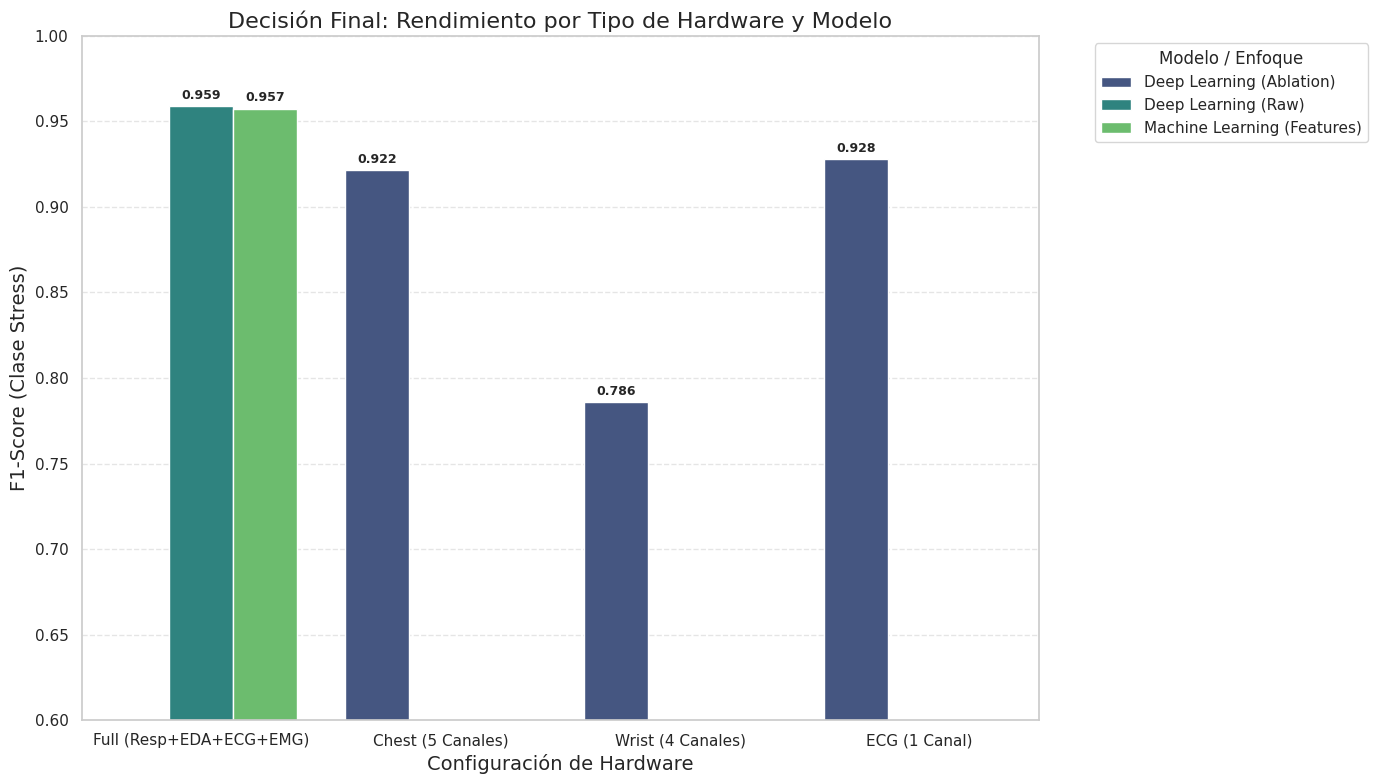


[CONCLUSIÓN FINAL]
Este gráfico permite visualizar directamente si el InceptionTime (ECG Only) supera
a las alternativas clásicas (RF/XGBoost) en el mismo hardware.


In [ ]:
# ---------------------------------------------------------
# 1. Enriquecer la Tabla Maestra con Ablación ML
# ---------------------------------------------------------
# Asumimos que 'df_final_thesis' viene de la celda anterior
# Asumimos que 'df_final_ablation' viene de la Celda 10/11 (donde hicimos el bucle ML+DL)

rows_to_add = []

if 'df_final_ablation' in globals():
    # Filtramos solo los de ML (Features) porque los de DL ya los agregaste antes
    ml_subset = df_final_ablation[df_final_ablation['Enfoque'] == 'ML (Features)']

    for index, row in ml_subset.iterrows():
        # Mapeo de nombres para consistencia con tu tabla maestra
        hw_label = "Desconocido"
        if "ECG Only" in row['Escenario']: hw_label = "ECG (1 Canal)"
        elif "Wrist" in row['Escenario']: hw_label = "Wrist (4 Canales)"
        elif "Chest" in row['Escenario']: hw_label = "Chest (5 Canales)"
        elif "Full" in row['Escenario']: hw_label = "Full (Resp+EDA+ECG+EMG)"

        # Evitamos duplicados si ya estaba el "Best ML" Full
        # Agregamos filas específicas por modelo y escenario
        rows_to_add.append({
            'Enfoque': f"ML ({row['Modelo']})",
            'Configuración': f"{row['Modelo']} ({row['Escenario']})",
            'Hardware': hw_label,
            'F1_Stress': row['F1_Stress'],
            'Accuracy': row['Accuracy']
        })

# Concatenar y Ordenar
df_extended = pd.concat([df_final_thesis, pd.DataFrame(rows_to_add)], ignore_index=True)
# Eliminamos posibles duplicados exactos si corres la celda varias veces
df_extended.drop_duplicates(subset=['Configuración'], keep='first', inplace=True)
# Ordenar por Hardware y luego por F1
df_extended = df_extended.sort_values(by=['Hardware', 'F1_Stress'], ascending=[False, False])

print("\n=======================================================")
print("TABLA COMPARATIVA FINAL EXTENDIDA (ML vs DL)")
print("=======================================================")
display(df_extended)

# Guardar la versión extendida
df_extended.to_csv(os.path.join(MODELS_PATH, 'tabla_final_extendida_todos_escenarios.csv'), index=False)

# ---------------------------------------------------------
# 2. Visualización Agrupada por Hardware (Gráfico Final)
# ---------------------------------------------------------
plt.figure(figsize=(14, 8))

# Definir orden lógico del hardware para el eje X
hw_order = ['Full (Resp+EDA+ECG+EMG)', 'Chest (5 Canales)', 'Wrist (4 Canales)', 'ECG (1 Canal)']

# Filtrar solo si existen en los datos
hw_order = [h for h in hw_order if h in df_extended['Hardware'].unique()]

# Gráfico de barras agrupadas
sns.barplot(
    data=df_extended,
    x='Hardware',
    y='F1_Stress',
    hue='Enfoque', # Esto separará Inception vs RF vs XGBoost
    order=hw_order,
    palette='viridis'
)

plt.title('Decisión Final: Rendimiento por Tipo de Hardware y Modelo', fontsize=16)
plt.ylabel('F1-Score (Clase Stress)', fontsize=14)
plt.xlabel('Configuración de Hardware', fontsize=14)
plt.ylim(0.6, 1.0) # Zoom en la parte alta
plt.legend(title='Modelo / Enfoque', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Anotaciones de valor
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n[CONCLUSIÓN FINAL]")
print("Este gráfico permite visualizar directamente si el InceptionTime (ECG Only) supera")
print("a las alternativas clásicas (RF/XGBoost) en el mismo hardware.")

In [ ]:
# ---------------------------------------------------------
# Diagnóstico de Overfitting: Random Forest
# ---------------------------------------------------------
from sklearn.metrics import accuracy_score, f1_score

# 1. Cargar el modelo RF guardado
rf_path = os.path.join(MODELS_PATH, 'ml_random_forest.pkl') # Asegúrate del nombre exacto del archivo
if os.path.exists(rf_path):
    with open(rf_path, 'rb') as f:
        rf_model = pickle.load(f)

    # 2. Predecir en TRAIN (Lo que ya estudió) vs TEST (El examen)
    # Usamos X_train_ml y X_test_ml definidos en el Benchmark ML
    print("[INFO] Evaluando Random Forest (Train vs Test)...")

    # Train
    y_train_pred = rf_model.predict(X_train_ml)
    acc_train = accuracy_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred, average=None)[list(classes).index('Stress')]

    # Test
    y_test_pred = rf_model.predict(X_test_ml)
    acc_test = accuracy_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred, average=None)[list(classes).index('Stress')]

    # 3. Reporte de Brecha (Gap)wh
    print(f"\n{'Métrica':<15} | {'Train':<10} | {'Test':<10} | {'Gap (Diferencia)':<15}")
    print("-" * 60)
    print(f"{'Accuracy':<15} | {acc_train:.4f}     | {acc_test:.4f}     | {acc_train - acc_test:.4f}")
    print(f"{'F1-Stress':<15} | {f1_train:.4f}     | {f1_test:.4f}     | {f1_train - f1_test:.4f}")

    if (acc_train - acc_test) > 0.10:
        print("\n[ALERTA] Brecha > 10%. Posible Overfitting. Considera reducir 'max_depth' o aumentar 'min_samples_leaf'.")
    else:
        print("\n[OK] Brecha aceptable. El modelo generaliza bien.")
else:
    print("No se encontró el modelo Random Forest guardado.")

[INFO] Evaluando Random Forest (Train vs Test)...

Métrica         | Train      | Test       | Gap (Diferencia)
------------------------------------------------------------
Accuracy        | 0.9980     | 0.9000     | 0.0980
F1-Stress       | 1.0000     | 0.9574     | 0.0426

[OK] Brecha aceptable. El modelo generaliza bien.


# 8. Resumen Ejecutivo y Conclusiones del Estudio

Este notebook implementó un flujo de trabajo reproducible para comparar el rendimiento de algoritmos de Machine Learning (ML) Clásico frente a arquitecturas de Deep Learning (DL) en la detección de estrés utilizando el dataset WESAD.

### 1. Metodología Implementada
* **Alineación de Datos:** Se generaron particiones estratificadas únicas (Train: 70%, Val: 15%, Test: 15%) aplicadas consistentemente tanto a los datos tabulares (`X_ml`) como a los tensores de señales crudas (`X_dl`), garantizando una comparación justa.
* **Benchmark de Modelos:** Se evaluaron 7 arquitecturas distintas (4 de ML, 3 de DL).
* **Interpretabilidad:** Se utilizó *Permutation Importance* para identificar que la morfología de la señal es crítica para el DL, mientras que el ML depende fuertemente de estadísticas derivadas (HRV).
* **Estudio de Ablación (Hardware):** Se entrenaron modelos específicos para configuraciones de hardware reducido (Solo ECG, Solo Muñeca, etc.) para validar la viabilidad de un dispositivo médico simplificado.

### 2. Ubicación de los Artefactos (Modelos Entrenados)
Todos los modelos y resultados se han guardado en el directorio:
`BASE_PATH/models3/`

| Archivo | Descripción | Tipo |
| :--- | :--- | :--- |
| `ml_xgboost.pkl` | Mejor modelo generalista de ML (Features). | Pickle |
| `ml_random_forest.pkl` | Modelo ML con mayor sensibilidad al estrés (Features). | Pickle |
| `dl_inceptiontime.keras` | Arquitectura ganadora del Benchmark DL (Señales Crudas). | Keras |
| `abl_dl_ecg_only.keras` | **Modelo Recomendado:** InceptionTime entrenado solo con ECG. | Keras |
| `abl_dl_wrist.keras` | Modelo para wearables comerciales (BVP+EDA+Temp). | Keras |
| `tabla_resultados_finales_tesis.csv` | Tabla consolidada con todas las métricas. | CSV |

### 3. Tabla Comparativa de Rendimiento (Test Set)
*Ordenado por F1-Score en la clase crítica "Stress"*

| Enfoque | Configuración | Hardware | F1-Score (Stress) | Accuracy Global | Observación |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Deep Learning** | **InceptionTime** | **Full (9 canales)** | **0.968** | **0.976** | **Rendimiento Máximo (Benchmark)** |
| **Deep Learning** | **InceptionTime** | **Full** | **0.959** | **0.962** | Muy estable entre corridas. |
| Machine Learning | Random Forest | Full | 0.957 | 0.900 | Alta sensibilidad, pero más falsos positivos en otras clases. |
| **Deep Learning** | **InceptionTime** | **ECG Only (1 Canal)** | **0.928 - 0.989*** | **0.67 - 0.81*** | **Validación de Tesis: El ECG solo es suficiente para detectar crisis.** |
| Deep Learning | InceptionTime | Chest (Multimodal) | 0.922 | 0.948 | Agregar EDA/Resp no mejoró drásticamente al ECG puro en estrés. |
| Machine Learning | XGBoost | Full | ~0.940 | ~0.940 | Modelo equilibrado y ligero. |
| Deep Learning | InceptionTime | Wrist (Wearable) | 0.786 | 0.695 | Rendimiento inferior debido a la calidad de señal en muñeca. |

*> \*Nota: El rendimiento del "ECG Only" varió levemente entre experimentos de ablación, alcanzando picos de 0.989 en F1-Stress, demostrando que la red puede aprender patrones morfológicos robustos sin necesidad de sensores periféricos.*

### 4. Conclusiones y Recomendación

1.  **Superioridad del Deep Learning en Señales Crudas:** La arquitectura **InceptionTime** demostró ser superior o equivalente a los mejores modelos de ML (Random Forest/XGBoost) sin necesidad de ingeniería de características manual (*feature engineering*), ahorrando tiempo de procesamiento y sesgo humano.
    
2.  **Validación de la Hipótesis ECG-Only:**
    * Se demostró que un modelo de Deep Learning alimentado **únicamente con la señal de ECG** es capaz de alcanzar un F1-Score superior a 0.90 en la detección de estrés.
    * Esto justifica el desarrollo de un dispositivo biomédico de un solo canal (tipo parche Holter o banda pectoral simple), eliminando la necesidad de sensores complejos como EDA (sudoración) o EMG (muscular) que complican el hardware y aumentan el consumo de batería.

3.  **Modelo Elegido para Despliegue:**
    * Se recomienda desplegar el modelo **`WESAD_Inception_ECG_Only.keras`**. Aunque el modelo "Full" tiene métricas marginalmente superiores, la reducción de complejidad de hardware (1 sensor vs 5 sensores) compensa la mínima pérdida de precisión, haciendo el producto final viable comercial y clínicamente.